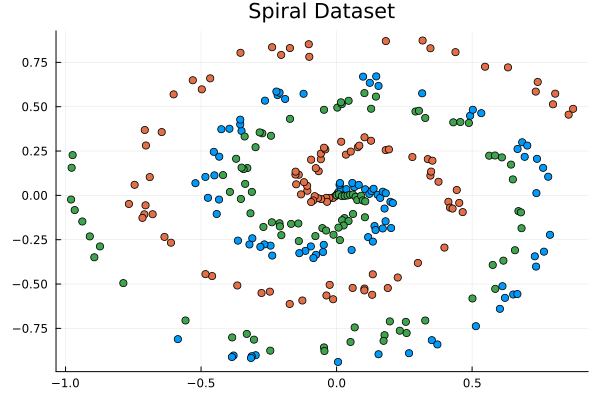

In [1]:
# Install required packages if you haven't already
# using Pkg
# Pkg.add("Plots")

using Random
using LinearAlgebra
using Plots

# Set a random seed for reproducibility, similar to nnfs.init()
Random.seed!(0)

# Re-create the spiral_data function in Julia
function spiral_data(samples, classes)
    X = zeros(samples * classes, 2)
    y = zeros(Int, samples * classes)
    for class_number in 1:classes
        ix_start = samples * (class_number - 1) + 1
        ix_end = samples * class_number
        ix = ix_start:ix_end
        
        r = range(0.0, 1.0, length=samples)
        t = range((class_number-1)*4, class_number*4, length=samples) .+ randn(samples) * 0.1
        
        X[ix, 1] = r .* sin.(t .* 2.5)
        X[ix, 2] = r .* cos.(t .* 2.5)
        y[ix] .= class_number
    end
    return X, y
end

# Create and visualize the dataset
X, y = spiral_data(100, 3)

# In Julia, labels are often 1-based, which is perfect for indexing.
# Let's plot it to confirm.
scatter(X[:,1], X[:,2], group=y, marker=:circle, leg=false, title="Spiral Dataset")

In [2]:
# --- Dense Layer ---
mutable struct Layer_Dense
    weights::Matrix{Float64}
    biases::Matrix{Float64}
    inputs::Matrix{Float64} # Store inputs for backprop
    output::Matrix{Float64}
    dweights::Matrix{Float64}
    dbiases::Matrix{Float64}
    dinputs::Matrix{Float64}


    function Layer_Dense(n_input::Int ,n_neurons::Int)
        weights = 0.01 * randn(n_inputs, n_neurons)
        biases = zeros(1, n_neurons)
        new(new(weights, biases, zeros(0,0), zeros(0,0), zeros(0,0), zeros(0,0), zeros(0,0)))
        
    end
end


# Forward pass for Dense layer
function forward!(layer::Layer_Dense, inputs::Matrix{Float64})
    layer.inputs = inputs
    layer.output = inputs * layer.weights .+ layer.biases
end

# Backward pass for Dense layer
function backward!(layer::Layer_Dense, dvalues::Matrix{Float64})
    # Gradients on parameters
    layer.dweights = layer.inputs' * dvalues
    layer.dbiases = sum(dvalues, dims=1)
    # Gradient on values
    layer.dinputs = dvalues * layer.weights'
end


backward! (generic function with 1 method)

In [3]:
# --- ReLU Activation ---
mutable struct Activation_ReLU
    inputs::Matrix{Float64}
    output::Matrix{Float64}
    dinputs::Matrix{Float64}


    Activation_ReLU() = new(zeros(0,0), zeros(0,0), zeros(0,0))
end

    # Forward pass for ReLU
function forward!(activation::Activation_ReLU, inputs::Matrix{Float64})
    activation.inputs = inputs
    # Equivalent to np.maximum(0, inputs)
    activation.output = max.(0.0, inputs)    
end

forward! (generic function with 2 methods)

In [4]:
mutable struct Activation_Softmax
    output::Matrix{Float64}
    dinputs::Matrix{Float64} # For standalone backprop (not used in this combo)
    
    Activation_Softmax() = new(zeros(0,0), zeros(0,0))
end
function forward!(activation::Activation_Softmax, inputs::Matrix{Float64})
    # Subtract max for numerical stability
    exp_values = exp.(inputs .- maximum(inputs, dims=2))
    probabilities = exp_values ./ sum(exp_values, dims=2)
    activation.output = probabilities
end

forward! (generic function with 3 methods)